<a href="https://colab.research.google.com/github/Jagannath-16/AI-ML-LAB/blob/main/labCycle1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#q1 load and basic
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)


print("\n")

print("Basic Information")
df.info()



Basic Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
#q2
print("Shape of Dataset")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\n")

print("Data Types")
print(df.dtypes)

print("\n")

print("Missing Values")
print(df.isnull().sum())

Shape of Dataset
(891, 12)

Number of Rows: 891
Number of Columns: 12


Data Types
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
#q3
print("First 5 Rows")
print(df.head())

print("\n")

print("Last 5 Rows")
print(df.tail())

print("\n")

print("Random 5 Rows")
print(df.sample(5))

First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

In [ ]:
#q4
df = df.drop(columns=["Cabin"])
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
print("Missing Values After Handling")
print(df.isnull().sum())

Missing Values After Handling
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
#q5
print("Duplicate Rows")
print(df.duplicated().sum())


Duplicate Rows
0


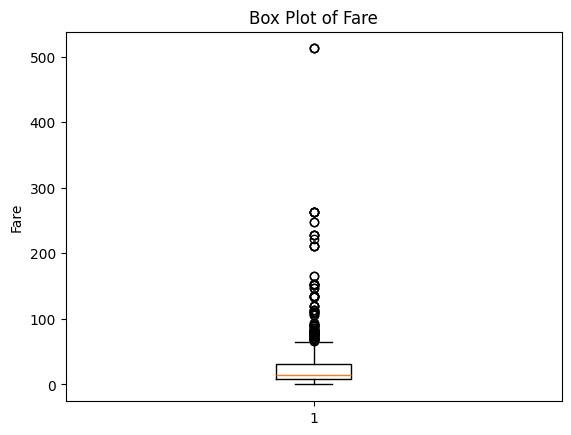

Outliers in Fare column:
     PassengerId  Survived  Pclass  \
1              2         1       1   
27            28         0       1   
31            32         1       1   
34            35         0       1   
52            53         1       1   
..           ...       ...     ...   
846          847         0       3   
849          850         1       1   
856          857         1       1   
863          864         0       3   
879          880         1       1   

                                                  Name     Sex   Age  SibSp  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
27                      Fortune, Mr. Charles Alexander    male  19.0      3   
31      Spencer, Mrs. William Augustus (Marie Eugenie)  female  28.0      1   
34                             Meyer, Mr. Edgar Joseph    male  28.0      1   
52            Harper, Mrs. Henry Sleeper (Myna Haxtun)  female  49.0      1   
..                                          

In [ ]:
#q6
import matplotlib.pyplot as plt

plt.boxplot(df["Fare"])
plt.title("Box Plot of Fare")
plt.ylabel("Fare")
plt.show()

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df["Fare"] < lower_limit) | (df["Fare"] > upper_limit)]

print("Outliers in Fare column:")
print(outliers)

print("\nNumber of outliers:", len(outliers))

Dataset shape after removing outliers:
(775, 11)


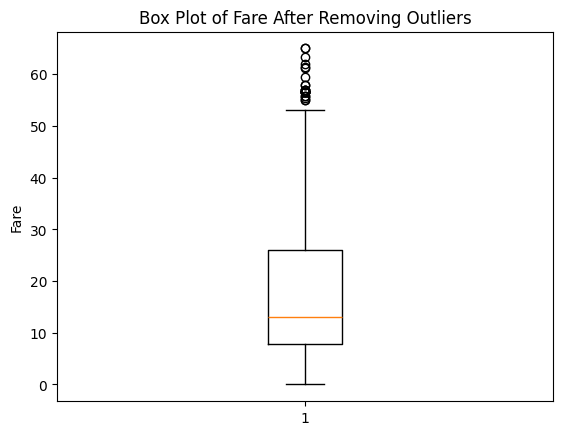

In [ ]:
#q7

df = df[(df["Fare"] >= lower_limit) & (df["Fare"] <= upper_limit)]

print("Dataset shape after removing outliers:")
print(df.shape)
import matplotlib.pyplot as plt

plt.boxplot(df["Fare"])
plt.title("Box Plot of Fare After Removing Outliers")
plt.ylabel("Fare")
plt.show()

In [ ]:
#q9
from sklearn.preprocessing import MinMaxScaler, StandardScaler
minmax = MinMaxScaler()

df["Fare_MinMax"] = minmax.fit_transform(df[["Fare"]])

print(df[["Fare", "Fare_MinMax"]].head())

standard = StandardScaler()

df["Fare_Standard"] = standard.fit_transform(df[["Fare"]])

print(df[["Fare", "Fare_Standard"]].head())

      Fare  Fare_MinMax
0   7.2500     0.111538
2   7.9250     0.121923
3  53.1000     0.816923
4   8.0500     0.123846
5   8.4583     0.130128
      Fare  Fare_Standard
0   7.2500      -0.779117
2   7.9250      -0.729373
3  53.1000       2.599828
4   8.0500      -0.720161
5   8.4583      -0.690071


               PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId       1.000000 -0.024438 -0.045179  0.016537 -0.080426 -0.015117   
Survived         -0.024438  1.000000 -0.238532 -0.118009 -0.003156  0.098575   
Pclass           -0.045179 -0.238532  1.000000 -0.349607  0.113943  0.083451   
Age               0.016537 -0.118009 -0.349607  1.000000 -0.335000 -0.204181   
SibSp            -0.080426 -0.003156  0.113943 -0.335000  1.000000  0.410182   
Parch            -0.015117  0.098575  0.083451 -0.204181  0.410182  1.000000   
Fare              0.002942  0.234422 -0.589776  0.085716  0.370388  0.336844   
Fare_MinMax       0.002942  0.234422 -0.589776  0.085716  0.370388  0.336844   
Fare_Standard     0.002942  0.234422 -0.589776  0.085716  0.370388  0.336844   

                   Fare  Fare_MinMax  Fare_Standard  
PassengerId    0.002942     0.002942       0.002942  
Survived       0.234422     0.234422       0.234422  
Pclass        -0.589776    -0.589776 

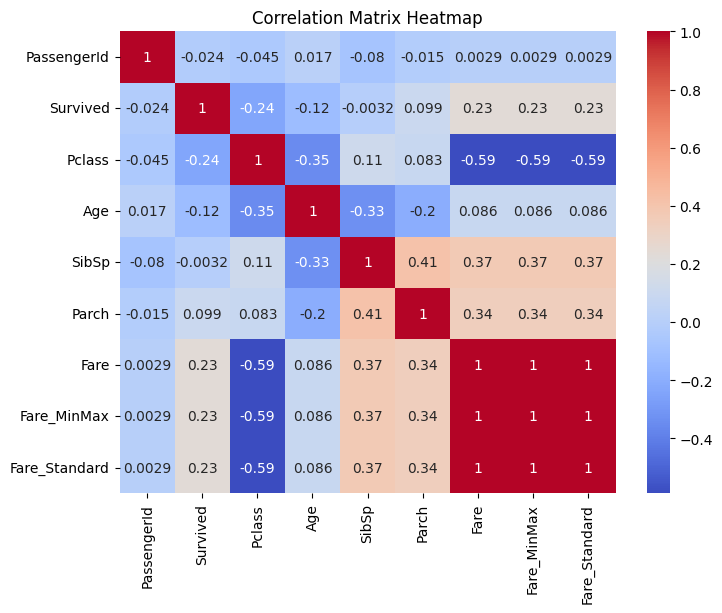

In [ ]:
#q11
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

plt.figure(figsize=(8,6))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
#q12
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

print(df[["SibSp", "Parch", "FamilySize"]].head())

   SibSp  Parch  FamilySize
0      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1
5      0      0           1


In [ ]:
#q13
df["Age"] = df["Age"].round().astype("Int64")

In [ ]:
#q14
df = df.rename(columns={
    "SibSp": "Siblings_Spouses",
    "Parch": "Parents_Children"
})
df["Embarked"] = df["Embarked"].str.strip()
df["Survived"] = df["Survived"].replace({
    0: "Not Survived",
    1: "Survived"
})


In [ ]:
#q15
from sklearn.model_selection import train_test_split

X = df[["Pclass", "Age", "Fare"]]

y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (620, 3)
Testing Data Shape: (155, 3)


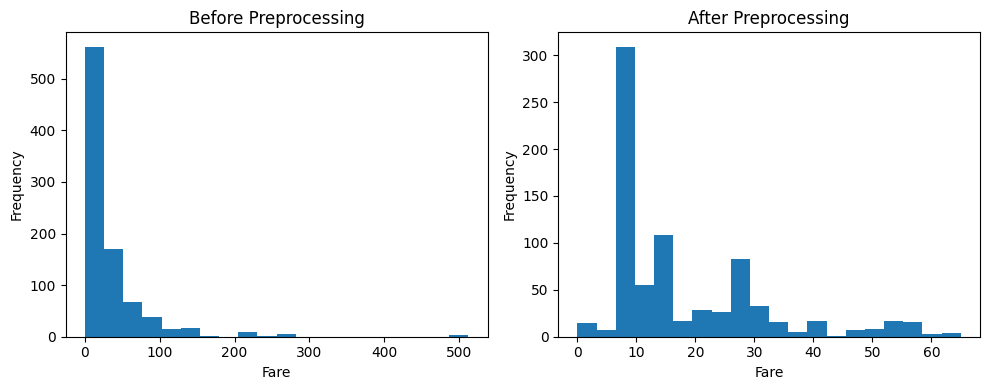

In [ ]:
#q17
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
original_df = pd.read_csv(url)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(original_df["Fare"].dropna(), bins=20)
plt.title("Before Preprocessing")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(df["Fare"], bins=20)
plt.title("After Preprocessing")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [ ]:
#q18
print("Original Dataset Shape:", original_df.shape)
print("Preprocessed Dataset Shape:", df.shape)

print("\nOriginal Columns:", original_df.columns.tolist())
print("\nPreprocessed Columns:", df.columns.tolist())

Original Dataset Shape: (891, 12)
Preprocessed Dataset Shape: (775, 14)

Original Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Preprocessed Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings_Spouses', 'Parents_Children', 'Ticket', 'Fare', 'Embarked', 'Fare_MinMax', 'Fare_Standard', 'FamilySize']


In [ ]:
#q19 saving only for now
df.to_csv("Titanic_Preprocessed.csv", index=False)

print("Dataset saved")

Dataset saved


In [ ]:
print(df)

     PassengerId      Survived  Pclass  \
0              1  Not Survived       3   
2              3      Survived       3   
3              4      Survived       1   
4              5  Not Survived       3   
5              6  Not Survived       3   
..           ...           ...     ...   
886          887  Not Survived       2   
887          888      Survived       1   
888          889  Not Survived       3   
889          890      Survived       1   
890          891  Not Survived       3   

                                             Name     Sex  Age  \
0                         Braund, Mr. Owen Harris    male   22   
2                          Heikkinen, Miss. Laina  female   26   
3    Futrelle, Mrs. Jacques Heath (Lily May Peel)  female   35   
4                        Allen, Mr. William Henry    male   35   
5                                Moran, Mr. James    male   28   
..                                            ...     ...  ...   
886                         Montv